# 03a — Logistic Regression (Primary Model)

## Why Logistic Regression First?

Logistic Regression is the **primary model** in this project — not because it is the most powerful, but because it is the most appropriate for our goal.

This project is about **decision support**, not maximum accuracy. Logistic Regression offers:

| Property | Why It Matters Here |
|---|---|
| Interpretable coefficients | We can explain *why* a customer is predicted to churn |
| Direct probability output | Enables risk ranking of customers |
| Stable behavior | Reliable across different data samples |
| Hypothesis alignment | Coefficients can validate H1 and H2 findings |

---

## Class Imbalance Strategy: `class_weight='balanced'`

The dataset has ~26.6% churners. Without correction, the model would bias toward predicting 'No churn' since that is the majority class.

`class_weight='balanced'` automatically adjusts the loss function to penalize missed churners more heavily — proportional to how underrepresented they are. This is the most transparent and reproducible approach.

---

## 1. Imports and Data Loading

In [7]:
import sys
sys.path.append('../../src')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

from modeling import (
    split_data,
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curve,
    print_metrics_table,
    save_model,
)

df = pd.read_csv('../../data/featured_churn.csv')

print('Loaded featured data.')
print('Shape:', df.shape)
print('Churn rate:', round(df['Churn'].mean() * 100, 1), '%')

Loaded featured data.
Shape: (7032, 32)
Churn rate: 26.6 %


---
## 2. Train / Test Split

80/20 stratified split — stratification ensures both train and test sets maintain the same ~26.6% churn ratio.

In [8]:
X_train, X_test, y_train, y_test = split_data(df)

print(f'Training set : {X_train.shape[0]} rows  |  Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test set     : {X_test.shape[0]} rows  |  Churn rate: {y_test.mean()*100:.1f}%')

Training set : 5625 rows  |  Churn rate: 26.6%
Test set     : 1407 rows  |  Churn rate: 26.6%


---
## 3. Train Logistic Regression

In [9]:
lr_model = LogisticRegression(
    class_weight='balanced',   # handles class imbalance
    max_iter=1000,             # enough iterations to converge
    random_state=42,
    solver='lbfgs'             # efficient for medium-sized datasets
)

lr_model.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


---
## 4. Evaluation

In [10]:
metrics = evaluate_model(lr_model, X_test, y_test)
print_metrics_table(metrics, model_name='Logistic Regression')


  Logistic Regression — Evaluation Results
  ROC-AUC     : 0.8353  ◄ primary
  Recall      : 0.7941  ◄ business priority
  Precision   : 0.4901
  F1          : 0.6061
  Accuracy    : 0.7257



---
## 5. Confusion Matrix

False Negatives (missed churners) are the most costly outcome — a missed churner is a lost customer.
False Positives (wrong alerts) waste retention budget but are less damaging.

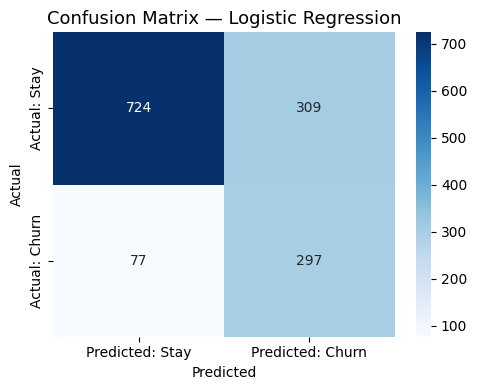

  True Positives  (caught churners):  297
  False Negatives (missed churners):  77  ← business cost
  False Positives (wrong alerts):     309
  True Negatives  (correct stays):    724


In [11]:
plot_confusion_matrix(lr_model, X_test, y_test, model_name='Logistic Regression')

---
## 6. ROC Curve

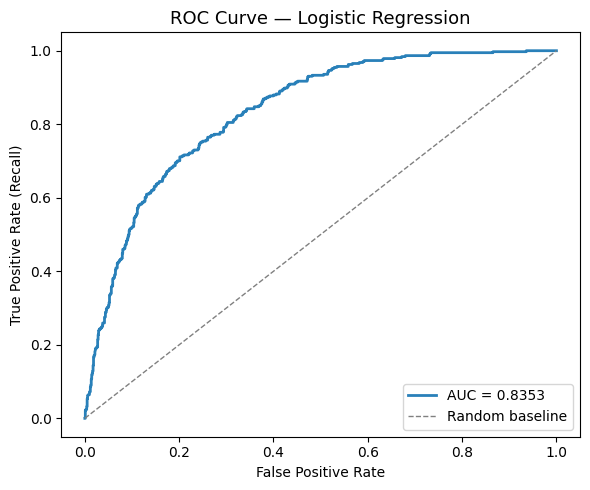

In [12]:
plot_roc_curve(lr_model, X_test, y_test, model_name='Logistic Regression')

---
## 7. Coefficient Analysis (Hypothesis Validation)

One of the unique advantages of Logistic Regression — we can inspect coefficients to validate our hypotheses.

- **Positive coefficient** → feature increases churn probability
- **Negative coefficient** → feature decreases churn probability

We expect `Contract` to have a strong negative coefficient (higher contract = lower churn) and `PaymentMethod_Electronic_check` to have a positive coefficient — both confirming H1 and H2.

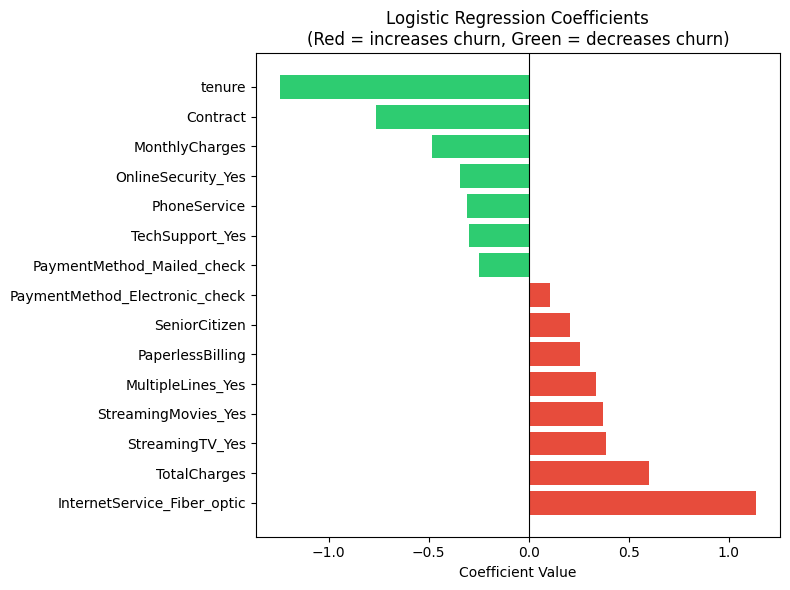


Top churn-increasing features:
                    Feature  Coefficient
InternetService_Fiber_optic     1.137124
               TotalCharges     0.599259
            StreamingTV_Yes     0.383957
        StreamingMovies_Yes     0.371343
          MultipleLines_Yes     0.338258

Top churn-reducing features:
           Feature  Coefficient
      PhoneService    -0.309543
OnlineSecurity_Yes    -0.345803
    MonthlyCharges    -0.484950
          Contract    -0.761174
            tenure    -1.245194


In [13]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

# Top 15 most influential features
top_features = pd.concat([
    coef_df.head(8),
    coef_df.tail(7)
])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_features['Coefficient']]
ax.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(Red = increases churn, Green = decreases churn)', fontsize=12)
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print('\nTop churn-increasing features:')
print(coef_df.head(5).to_string(index=False))
print('\nTop churn-reducing features:')
print(coef_df.tail(5).to_string(index=False))

---
## 8. Save Model

In [14]:
save_model(lr_model, 'logistic_regression', folder='../../models')
print('Logistic Regression model saved. Proceed to 03b_random_forest.ipynb')

Model saved to: ../../models\logistic_regression.pkl
Logistic Regression model saved. Proceed to 03b_random_forest.ipynb


---
## Summary

Logistic Regression serves as the **interpretable baseline** for this project.

Its coefficient analysis directly validates the hypotheses formed in EDA:
- H1 (Contract type) and H2 (Payment method) should appear as influential features
- This creates a direct evidence chain: **hypothesis → EDA → model confirmation**

Next: `03b_random_forest.ipynb` — benchmark comparison.